# **1. Perkenalan Dataset**


*   **Nama Dataset:** Telco Customer Churn
*   **Sumber:** IBM Sample Data Sets (via Kaggle)
*   **Jumlah Baris:** 7043
*   **Jumlah Kolom:** 21
*   **Tujuan:** Memprediksi apakah pelanggan akan churn (berhenti berlangganan) atau tidak.


**Fitur Utama:**
- `customerID`: ID unik pelanggan
- `tenure`: lama berlangganan (bulan)
- `MonthlyCharges`: tagihan bulanan
- `TotalCharges`: total tagihan
- `Churn`: target (Yes/No)

# **2. Import Library**

Mengimport beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# 2. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

# **3. Memuat Dataset**

Dataset Telco Customer Churn adalah **strutured data** dengan format file **CSV**

In [2]:
# 3. Memuat Dataset
df = pd.read_csv('telco_churn.csv')

print("Shape dataset:", df.shape)
print("\n5 baris pertama:")
df.head()

Shape dataset: (7043, 21)

5 baris pertama:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Cek Info dan Tipe Data

In [3]:
df.info()
print("\nStatistik deskriptif:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Cek Missing Values & Duplikat

In [4]:
print("Missing values per kolom:")
print(df.isnull().sum())

print("\nJumlah duplikat:", df.duplicated().sum())

Missing values per kolom:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Jumlah duplikat: 0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, **Exploratory Data Analysis (EDA)** dilakukan untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

## 4.1 Distribusi Target

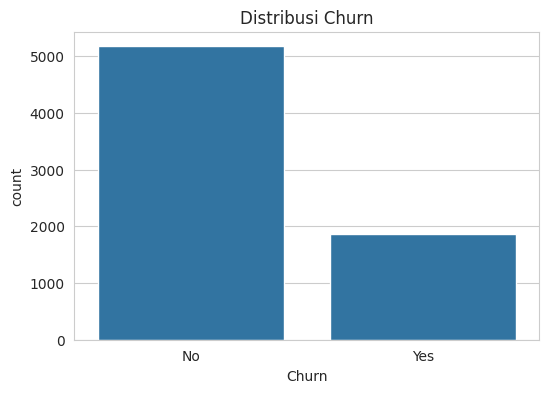

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [5]:
# Distribusi target
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Distribusi Churn')
plt.show()

print(df['Churn'].value_counts(normalize=True))

## 4.2 Distribusi Fitur Numerik

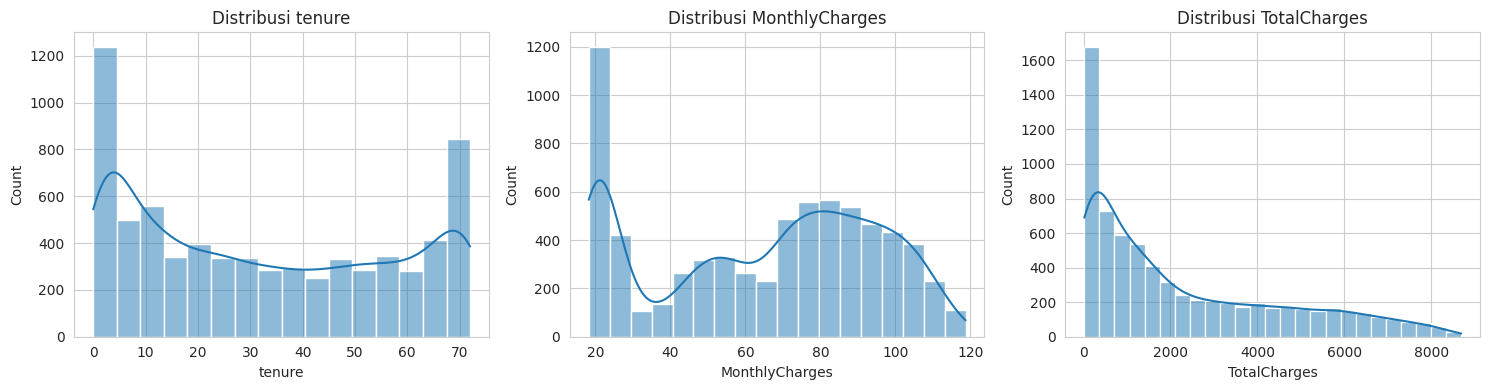


Statistik fitur numerik:
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7032.000000
mean     32.371149       64.761692   2283.300441
std      24.559481       30.090047   2266.771362
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.850000   3794.737500
max      72.000000      118.750000   8684.800000


In [6]:
# Distribusi Fitur Numerik
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(num_cols):
    sns.histplot(df_eda[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

print("\nStatistik fitur numerik:")
print(df_eda[num_cols].describe())

## 4.3 Hubungan Fitur Kategorikal dengan Target

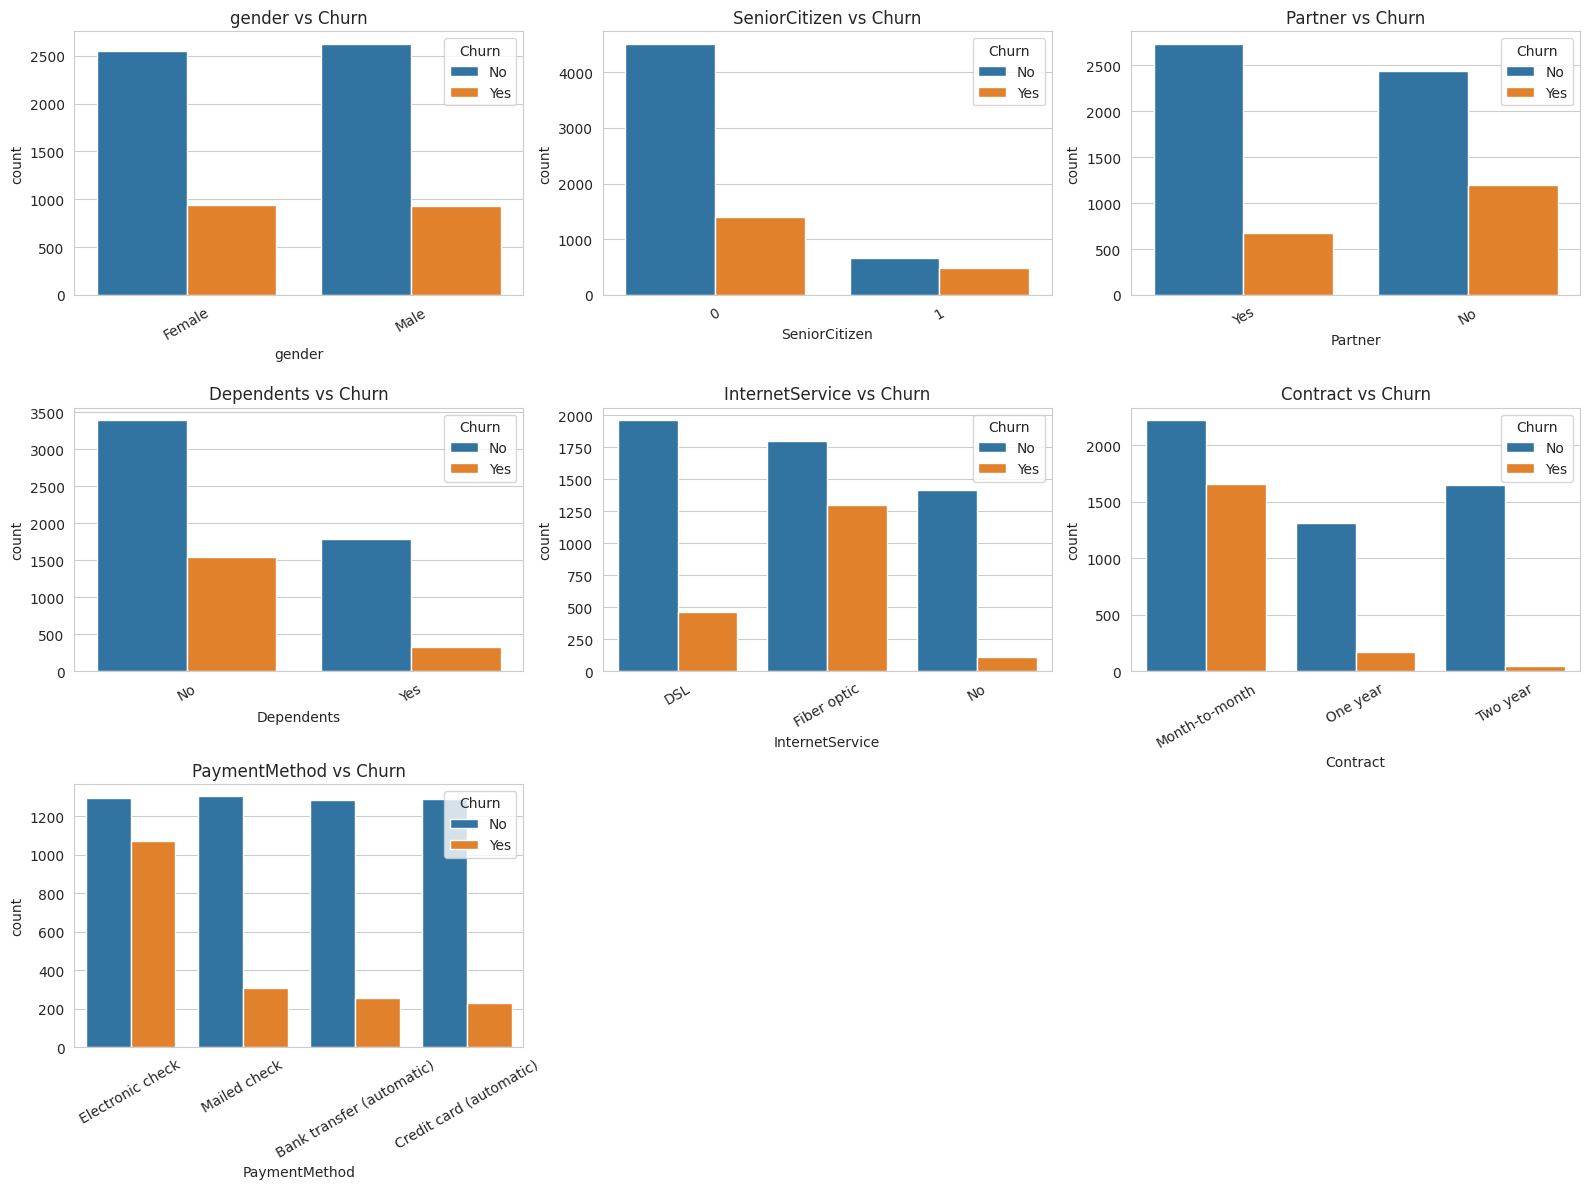

In [7]:
# Hubungan Fitur Kategorikal dengan Target
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'InternetService', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(3, 3, figsize=(16,12))
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'{col} vs Churn')
    axes[i//3, i%3].tick_params(axis='x', rotation=30)

# Hapus subplot kosong
for j in range(len(cat_cols), 9):
    fig.delaxes(axes[j//3, j%3])

plt.tight_layout()
plt.show()

## 4.4 Korelasi Fitur Numerik

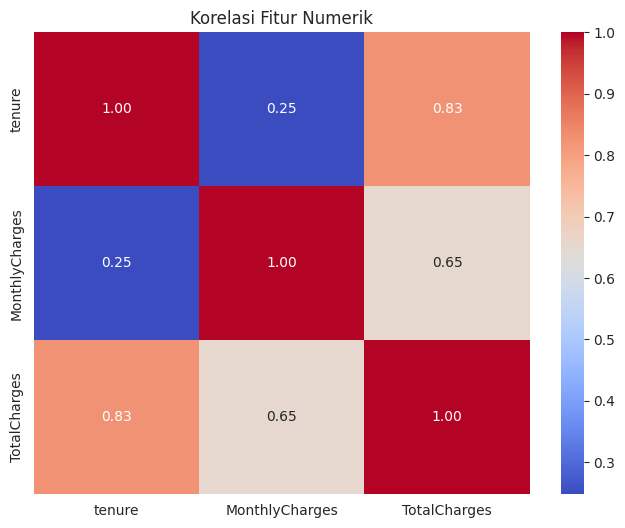


Matriks korelasi:
                 tenure  MonthlyCharges  TotalCharges
tenure          1.00000        0.247900      0.825880
MonthlyCharges  0.24790        1.000000      0.651065
TotalCharges    0.82588        0.651065      1.000000


In [8]:
# Korelasi Fitur Numerik
plt.figure(figsize=(8,6))
sns.heatmap(df_eda[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Fitur Numerik')
plt.show()

print("\nMatriks korelasi:")
print(df_eda[num_cols].corr())

## 4.5 Cek Missing & Duplikat

In [9]:
# Cek Missing Values & Duplikat
print("Missing values per kolom:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nJumlah duplikat:", df.duplicated().sum())

# Cek nilai aneh di TotalCharges
print("\nContoh nilai TotalCharges yang bukan numerik:")
print(df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]['TotalCharges'].head())

Missing values per kolom:
Series([], dtype: int64)

Jumlah duplikat: 0

Contoh nilai TotalCharges yang bukan numerik:
488      
753      
936      
1082     
1340     
Name: TotalCharges, dtype: object


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

## 5.1 Hapus Kolom Tidak Relevan

In [10]:
# Hapus kolom tidak relevan
df_clean = df.copy()

if 'customerID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['customerID'])
    print("Kolom 'customerID' dihapus.")
else:
    print("Kolom 'customerID' tidak ditemukan.")

print("Shape setelah drop:", df_clean.shape)

Kolom 'customerID' dihapus.
Shape setelah drop: (7043, 20)


## 5.2 Handle TotalCharges

In [11]:
# Handle TotalCharges (spasi kosong -> NaN -> numerik)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

print("Tipe data TotalCharges:", df_clean['TotalCharges'].dtype)
print("Jumlah missing TotalCharges:", df_clean['TotalCharges'].isnull().sum())

Tipe data TotalCharges: float64
Jumlah missing TotalCharges: 11


## 5.3 Imputasi Missing Value

In [12]:
# Imputasi missing value dengan median
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df_clean[['TotalCharges']] = imputer.fit_transform(df_clean[['TotalCharges']])

print("Missing setelah imputasi:", df_clean['TotalCharges'].isnull().sum())

Missing setelah imputasi: 0


## 5.4 Hapus Duplikat

In [13]:
# Hapus duplikat
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after = df_clean.shape[0]

print(f"Duplikat dihapus: {before - after} baris")
print("Shape setelah drop duplikat:", df_clean.shape)

Duplikat dihapus: 22 baris
Shape setelah drop duplikat: (7021, 20)


## 5.5 Encoding Target

In [14]:
# Encoding target Churn
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print("Distribusi target setelah encoding:")
print(df_clean['Churn'].value_counts())

Distribusi target setelah encoding:
Churn
0    5164
1    1857
Name: count, dtype: int64


## 5.6 Encoding Fitur Kategorikal

In [15]:
# Encoding fitur kategorikal (One-Hot Encoding)
cat_cols_to_encode = df_clean.select_dtypes(include='object').columns.tolist()
print("Kolom kategorikal yang di-encode:", cat_cols_to_encode)

df_clean = pd.get_dummies(df_clean, columns=cat_cols_to_encode, drop_first=True)

print("Shape setelah encoding:", df_clean.shape)

Kolom kategorikal yang di-encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape setelah encoding: (7021, 31)


## 5.7 Standarisasi Fitur Numerik

In [16]:
# Standarisasi fitur numerik
from sklearn.preprocessing import StandardScaler

num_cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df_clean[num_cols_to_scale] = scaler.fit_transform(df_clean[num_cols_to_scale])

print("Statistik setelah scaling:")
print(df_clean[num_cols_to_scale].describe().round(3))

Statistik setelah scaling:
         tenure  MonthlyCharges  TotalCharges
count  7021.000        7021.000      7021.000
mean      0.000          -0.000        -0.000
std       1.000           1.000         1.000
min      -1.323          -1.550        -1.002
25%      -0.957          -0.968        -0.829
50%      -0.141           0.185        -0.392
75%       0.918           0.833         0.668
max       1.611           1.793         2.824


## 5.8 Verifikasi Akhir

In [17]:
# Verifikasi hasil akhir
print("Shape akhir:", df_clean.shape)
print("\nMissing values akhir:", df_clean.isnull().sum().sum())
print("\nTipe data:")
print(df_clean.dtypes.value_counts())

df_clean.head()

Shape akhir: (7021, 31)

Missing values akhir: 0

Tipe data:
bool       26
float64     3
int64       2
Name: count, dtype: int64


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.282728,-1.164135,-0.997328,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,0.062387,-0.262811,-0.176347,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,-1.241967,-0.365914,-0.962760,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,0.510759,-0.750058,-0.197869,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,-1.241967,0.194503,-0.943556,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


## 5.9 Simpan Dataset

In [18]:
# Simpan dataset hasil preprocessing
import os

os.makedirs('namadataset_preprocessing', exist_ok=True)
output_path = 'namadataset_preprocessing/telco_churn_preprocessing.csv'
df_clean.to_csv(output_path, index=False)

print(f"Dataset tersimpan di: {output_path}")
print(f"Total baris: {df_clean.shape[0]}, Total kolom: {df_clean.shape[1]}")

Dataset tersimpan di: namadataset_preprocessing/telco_churn_preprocessing.csv
Total baris: 7021, Total kolom: 31
